In [1]:
using LinearAlgebra # for benchmarking against CPU LU and CUDA LU
using KernelAbstractions
using BenchmarkTools
using CUDA
using Printf
using Plots

# Helper Functions - not used for Tile LU directly #

In [2]:
#=
This code handles creating large P matrices for the kernel.
=#

@kernel function P_kernel!(P)
    I = @index(Global)
    P[I, I] = 1
end

function make_P(n, backend)
    final_P = CUDA.zeros(Float64, (n, n))
    P_kernel!(backend,256)(final_P, ndrange=(n))
    return final_P
end

make_P (generic function with 1 method)

In [3]:
#= returns the indices of a tile at index i of size n, used to make code cleaner =#

function ind(i, n)
    return ((i-1)*n+1:(i)*n)
end

ind (generic function with 1 method)

In [4]:
# Gets L and U from A for checking purposes since the tile LU function returns a single matrix
# that contains U on the top right corner and L on the bottom left corner (minus the diagonal of 1s)

function get_L_and_U(A)
    rows = size(A)[2]
    cols = size(A)[1]
    L = Float64.(I[1:cols, 1:min(rows,cols)])
    U = zeros(min(rows, cols), rows)

    for i = 1:min(rows, cols)
        for j = i:rows
            U[i, j] = A[i, j]
        end
    end

    for i = 1:cols
        for j = 1:min(rows, i-1)
            L[i, j] = A[i, j]
        end
    end

    return Dict("L" => L, "U" => U)
end

get_L_and_U (generic function with 1 method)

In [5]:
# Used for checking results -> takes two matrices and ensures no element differs by more than e
# used because precision of LU is not enough for both matrices to be identical for floating point
# operations

function matrix_checker(A, B, e)
    errs = 0
    for i = 1:size(A)[1]
        for j = 1:size(A)[2]
            if(A[i, j] - B[i, j] > e)
                print("mismatch at ")
                print(i)
                print(", ")
                print(j)
                print(": ")
                print(A[i, j])
                print(" vs ")
                print(B[i, j])
                println()
                errs += 1
            end
        end
    end
    if errs == 0
        println("Matrices match!")
    end
end

matrix_checker (generic function with 1 method)

# Tile LU Functions #

In [6]:
# Standard LU using only GPU (this limits the size of the tile to around 30ish by 30ish max)

function get_l_vals!(A, k, p, row_start, col_start, I, temp)
    A[I+p, k] = A[I+p, k] / A[k, k]
end

# not used
function create_U!(A, k, p, col_start, row_start, I, L)
    L = L + row_start
    A[I+p, L+k-col_start] = A[I+p, L+k-col_start] - A[I+p, k+row_start-col_start]*A[k, L+k-col_start]
end

function swap_rows!(A, i, j, start_row, temp, I)
    I = I+start_row-1
    temp = A[i, I]
    @inbounds A[i, I] = A[j, I]
    @inbounds A[j, I] = temp
end

# M and max_ind are used to find pivoting column
# pivot is set to true if pivoting is used (should always be true)
# next is no longer used, previously was used to determine what first row to start on is
# this will factor a tile A[row_start:row_stop, col_start:col_stop] although for dtstrf they should be identical bc diagonal tiles only
@kernel function lu_gpu!(A, P, M, max_ind, pivot, next, col_start, col_stop, row_start, row_stop)
    I, J = @index(Global, NTuple)
    temp = 0

    
    for k = row_start:row_stop
        col_k = k-row_start+col_start      
        offset = max(next-1, col_k)
        
        #find max in col
        if pivot
            M[1] = -100000.0
            @synchronize
            
            for j = col_k:col_stop
                M[1] = max(M[1], A[j, k])
                if A[j, k] == M[1] 
                    max_ind[1] = j
                end
            end 
            
            @synchronize
            
            if I <= row_stop-row_start+1 && J == 1
                swap_rows!(A, col_k, max_ind[1], row_start, temp, I)
                swap_rows!(P, col_k, max_ind[1], row_start, temp, I)
            end
            @synchronize
        end

        if I <= col_stop-offset && J == 1
            get_l_vals!(A, k, offset, row_start, col_start, I, temp)
        end
        
        @synchronize
        
        # this gets U values, I think the actual function had indexing errors so I just used this
        if I+col_start > offset && I+col_start <= col_stop && J+row_start <= row_stop && J+row_start > k
            A[I+col_start, J+row_start] = A[I+col_start, J+row_start] - A[I+col_start, k]*A[k, J+row_start]
        end
        @synchronize
    end
end

lu_gpu! (generic function with 4 methods)

In [7]:
#does square LU factorization on a diagonal tile of A, replaces tile of U with factored A

# A - the tile
# P - permutation matrix
# k - the current diagonal index we're on
# n - tile size
# M, max_ind, and backend are handled in tile LU, these are auxillary things needed for LU

function dgetrf!(A, P, k, n, M, max_ind, backend)
    lu_gpu!(backend, (n, n))(A, P, M, max_ind, true, 1, (k-1)*n+1, k*n, (k-1)*n+1, k*n, ndrange = (n, n))
end

dgetrf! (generic function with 1 method)

In [8]:
# L_inv matrix must have 1s along the diagonal
# This calculates the inverse of a tile that is already factored into LU, used for DGESSM
# L - The factored tile, L_inv - a tile with 1s along diagonal, n - tile size, k_ind - which diag ind we're on

@kernel function L_inv_single_kernel!(L, L_inv, n, k_ind)
    I = @index(Global)
    k_tile = (k_ind-1)*n
    
    for i = 2:n
        if I <= i-1
            L_inv[i, I] = 0
        end
        @synchronize
        for k = 1:i-1 
            if I <= i-1
                L_inv[i, I] -= (L[i+k_tile, k+k_tile]*L_inv[k, I])
            end
            @synchronize
        end
    end
end

L_inv_single_kernel! (generic function with 4 methods)

In [9]:
# This does the two matrix multiplications for L_inv and P to the fight

#A = matrix that is change 
# P = permutation matrix
# k_ind - diag value we are on
# offset - how far right to start
# n = size of tile
# temp = placeholder (probably can be removed)

@kernel function dgessm_kernel_P!(A, P, k_ind, offset, n, temp)
    i, j, j_ind = @index(Global, NTuple)
    j_ind = offset+j_ind

    for s = 1:n
        temp += P[i+(k_ind-1)*n,s+(k_ind-1)*n] * A[s+(k_ind-1)*n, j+(j_ind-1)*n]
    end

    A[i+(k_ind-1)*n,j+(j_ind-1)*n] = temp

end

@kernel function dgessm_kernel_L_inv!(A, L_inv, k_ind, n, temp)
    i, j, j_ind = @index(Global, NTuple)
    j_ind = j_ind + k_ind

    for s = 1:n
        temp += L_inv[i,s] * A[s+(k_ind-1)*n, j+(j_ind-1)*n]
    end

    A[i+(k_ind-1)*n,j+(j_ind-1)*n] = temp
end

dgessm_kernel_L_inv! (generic function with 4 methods)

In [10]:
# A new LU specifically written for DTSTRF
# DTSTRF needs to do seperate LUs on every tile below the diagonal using the U of the diagonal
# this kernel handles it all in one kernel, also limits tile size to about 30 by 30
# making it all one kernel is significantly faster than communicating back and forth
# almost identical to other LU except no pivoting

@kernel function single_dtstrf_lu_gpu!(A, next, k, tiles_col, row_start, row_stop)
    I, J = @index(Global, NTuple)
    temp = 0
    n = @uniform @groupsize()[1]
    
    # local memory is used since values in each tile is fetched multiple times
    local_A = @localmem eltype(A) (n,n)
    
    local_A_upper = @localmem eltype(A) (n,n)
    
    # this could theoretically make it faster but I just haven't tried it yet
    #local_A_upper[I, J] = A[I+row_start-1, J+row_start-1]
    #@synchronize
    
    for i = k+1:tiles_col
        
        col_start = (i-1)*n
        col_stop = (i)*n
    
        local_A[I, J] = A[I+col_start, J+row_start-1]
        @synchronize

        for k = row_start:row_stop
            col_k = k-row_start+col_start      
            offset = max(next-1, col_k)

            if J == 1
                local_A[I, k-row_start+1] = local_A[I, k-row_start+1]/A[k, k]
            end

            @synchronize


            if J+k <= row_stop # && J+row_start > k
                local_A[I, J+k-row_start+1] = local_A[I, J+k-row_start+1] - local_A[I, k-row_start+1]*A[k, J+k]
            end
            @synchronize
        end

        A[I+col_start, J+row_start-1] = local_A[I, J]
        @synchronize
        
    end
    
end

single_dtstrf_lu_gpu! (generic function with 4 methods)

In [11]:
# k is current diagonal, J_ind is below diagonal, I_ind is to right of diagonal
# handles dssssm for entire trailing submatrix

@kernel function dssssm_kernel!(A, k, n, temp)
    i, j, j_ind, i_ind = @index(Global, NTuple)
    j_ind = j_ind + k
    i_ind = i_ind + k

    for s = 1:n
        temp -= A[i+(j_ind-1)*n,s+(k-1)*n] * A[s+(k-1)*n, j+(i_ind-1)*n]
    end

    A[i+(j_ind-1)*n,j+(i_ind-1)*n] += temp
end

dssssm_kernel! (generic function with 4 methods)

In [12]:
# modifies old matrix A as L and U, and returns a P holding permutation matrix such that P*L*U = old A

function tile_lu_factor!(A, n)
    
    # necessary auxillary cuda matrices
    M = CuArray([-10000.0, -1000.0])
    max_ind = CuArray([1, 1])
    L_for_gessm = CuArray(Float64.(I[1:n, 1:n]))
    backend = get_backend(A)

    # dimensions
    num_rows = size(A)[2] #this is actually number of columns but I wrote the entire thing like this so
    num_cols = size(A)[1]
    
    # creating P
    final_P = CUDA.zeros(Float64, (num_rows, num_rows))
    P_kernel!(backend,256)(final_P, ndrange=(num_rows))

    # matrix dimensions must be a multiple of tile size
    @assert num_rows%n==0 "The number of columns in the matrix is not divisible by n!"
    @assert num_cols%n==0 "The number of rows in the matrix is not divisible by n!"

    #determine how many tiles are in rows/cols of matrix
    tiles_row = num_rows÷n
    tiles_col = num_cols÷n

    # probably unnecessary
    temp = zero(eltype(A))

    for k = 1:min(tiles_row, tiles_col)
        # this modifies A and final_P
        dgetrf!(A, final_P, k, n, M, max_ind, backend)

        # this modifies L_for_gesssm
        L_inv_single_kernel!(backend, 256)(A, L_for_gessm, n, k, ndrange = (n-1))
        
        # the two dgessm steps modify A
        dgessm_kernel_P!(backend, 256)(A, final_P, k, k, n, temp, ndrange=(n, n, tiles_row-k))
        dgessm_kernel_L_inv!(backend, 256)(A, L_for_gessm, k, n, temp, ndrange=(n, n, tiles_row-k))

        # propogates all changes from factoring tile kk to left and modifies A
        dgessm_kernel_P!(backend, 256)(A, final_P, k, 0, n, temp, ndrange=(n, n, k-1))
        
        # modifies A
        single_dtstrf_lu_gpu!(backend, (n, n))(A, 1, k, tiles_col, (k-1)*n+1, k*n, ndrange = (n, n))

        # modifies A
        dssssm_kernel!(backend, 256)(A, k, n, temp, ndrange=(n, n, tiles_col-k, tiles_row-k))
    end
    
    return final_P
end

tile_lu_factor! (generic function with 1 method)

# Example running of Tile LU on 100 by 100 with tile size 10 #

In [13]:
a = 100
n = 10
A_copy = rand(a, a)
A = CuArray(A_copy[:,:])

A

100×100 CuArray{Float64, 2, CUDA.Mem.DeviceBuffer}:
 0.0983493  0.605222    0.503114    …  0.924822   0.173805    0.372149
 0.0849009  0.0569102   0.556159       0.891363   0.360347    0.886672
 0.759632   0.228567    0.337035       0.735503   0.8948      0.433466
 0.464153   0.799761    0.239151       0.931298   0.945995    0.75327
 0.135522   0.87088     0.114816       0.016341   0.198973    0.80762
 0.20162    0.515893    0.041251    …  0.916764   0.456027    0.0496604
 0.312533   0.523044    0.00790946     0.991409   0.671589    0.411756
 0.033287   0.622595    0.697049       0.687762   0.153593    0.989804
 0.450923   0.891063    0.641519       0.241144   0.146412    0.277807
 0.142525   0.766556    0.266327       0.0350452  0.691358    0.00347357
 0.837794   0.759978    0.372265    …  0.469829   0.494095    0.982772
 0.221724   0.379368    0.215831       0.534645   0.110063    0.0225783
 0.183723   0.544462    0.03833        0.357349   0.846384    0.419085
 ⋮                     

In [14]:
final_P = tile_lu_factor!(A, n)
1

1

In [15]:
A_LU = get_L_and_U(Array(A))
P = Array(final_P)
acf = inv(P)*A_LU["L"]*A_LU["U"]

100×100 Matrix{Float64}:
 0.0983493  0.605222    0.503114    …  0.924822   0.173805    0.372149
 0.0849009  0.0569102   0.556159       0.891363   0.360347    0.886672
 0.759632   0.228567    0.337035       0.735503   0.8948      0.433466
 0.464153   0.799761    0.239151       0.931298   0.945995    0.75327
 0.135522   0.87088     0.114816       0.016341   0.198973    0.80762
 0.20162    0.515893    0.041251    …  0.916764   0.456027    0.0496604
 0.312533   0.523044    0.00790946     0.991409   0.671589    0.411756
 0.033287   0.622595    0.697049       0.687762   0.153593    0.989804
 0.450923   0.891063    0.641519       0.241144   0.146412    0.277807
 0.142525   0.766556    0.266327       0.0350452  0.691358    0.00347357
 0.837794   0.759978    0.372265    …  0.469829   0.494095    0.982772
 0.221724   0.379368    0.215831       0.534645   0.110063    0.0225783
 0.183723   0.544462    0.03833        0.357349   0.846384    0.419085
 ⋮                                  ⋱             

In [16]:
matrix_checker(A_copy, acf, 0.00001)
# it works!

Matrices match!


# Benchmarking #

In [17]:
tile_times = []
cuda_times = []
cpu_times = []


tile_times_mean = []
cuda_times_mean = []
cpu_times_mean = []

x_axis = 5:11

for exponent = 5:11
    a = 2^exponent
    n = 16

    t = @benchmark tile_lu_factor!(A, n) setup = (A = CuArray(rand(a, a)))
    display(a)
    #display(median(t.times)/1000000) # measuring ms
    push!(tile_times, median(t.times)/1000000)
    push!(tile_times_mean, mean(t.times)/1000000)
    
    t = @benchmark lu(A) setup=(A=rand(a, a))
    # display(median(t.times)/1000000)
    push!(cpu_times, median(t.times)/1000000)
    push!(cpu_times_mean, mean(t.times)/1000000)
    
    t = @benchmark lu(A) setup=(A=CuArray(rand(a, a)))
    # display(median(t.times)/1000000)
    push!(cuda_times, median(t.times)/1000000)
    push!(cuda_times_mean, mean(t.times)/1000000)
end

32

64

128

256

512

1024

2048

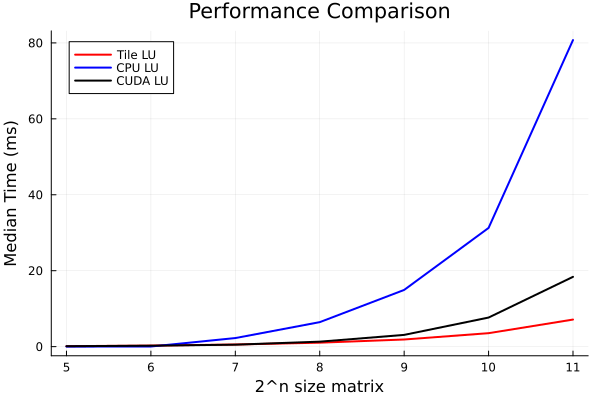

In [18]:
plot(x_axis, tile_times, label="Tile LU", color=:red, linewidth=2)
plot!(x_axis, cpu_times, label="CPU LU", color=:blue, linewidth=2)
plot!(x_axis, cuda_times, label="CUDA LU", color=:black, linewidth=2)

xlabel!("2^n size matrix")
ylabel!("Median Time (ms)")
title!("Performance Comparison")

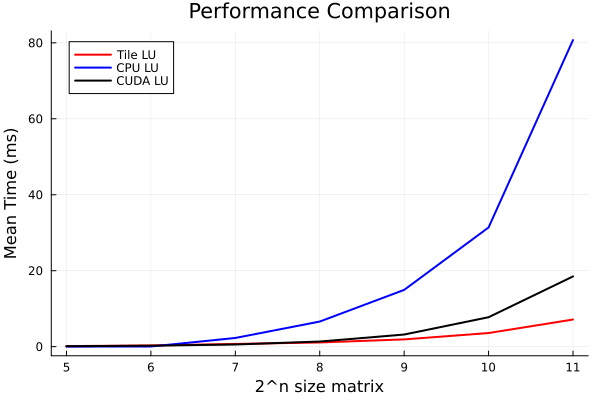

In [19]:
plot(x_axis, tile_times_mean, label="Tile LU", color=:red, linewidth=2)
plot!(x_axis, cpu_times_mean, label="CPU LU", color=:blue, linewidth=2)
plot!(x_axis, cuda_times_mean, label="CUDA LU", color=:black, linewidth=2)

xlabel!("2^n size matrix")
ylabel!("Mean Time (ms)")
title!("Performance Comparison")